# Implied Correlation Signal

This notebook will look at using implied correlation within trend following. 

# Packages & Paths

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
curr_path = os.getcwd()
research_path = os.path.abspath(os.path.join(curr_path, ".."))
repo_path     = os.path.abspath(os.path.join(research_path, ".."))
data_path     = os.path.join(repo_path, "data")
fut_path      = os.path.join(data_path, "FuturesData")
misc_path     = os.path.join(data_path, "MiscData")

In [3]:
tool_path = os.path.join(repo_path, "src", "Tools")
sys.path.append(tool_path)

from SignalTools import SignalAnalysis

# Getting Data

In [4]:
fut_px_path = os.path.join(fut_path, "PrepFuturesPX.parquet")
ic_px_path  = os.path.join(misc_path, "CleanedImpliedRealCorrelation.parquet")
ticker_path = os.path.join(misc_path, "ImpliedCorrelationTickerGuide.xlsx")

df_fut = (pd
    .read_parquet(path = fut_px_path, engine = "pyarrow"))

df_corr = (pd
    .read_parquet(path = ic_px_path, engine = "pyarrow")
    .loc[lambda x: x.file == "ImpliedCorr"]
    .drop(columns = ["file", "clean_val"])
    .rename(columns = {
        "variable": "eq_ticker",
        "Date"    : "date"})
    .drop_duplicates())

df_corr_fut_guide = (pd
    .read_excel(io = ticker_path, sheet_name = "TickerGuide")
    .rename(columns = {
        "Equity Index": "equity",
        "Future"      : "future"})
    .assign(
        equity = lambda x: x.equity.str.split(" ").str[0],
        future = lambda x: x.future.str.replace(" 1", "1").str.replace(" ", "_").str.lower())
    .dropna()
    .rename(columns = {"future": "ticker"})
    .loc[lambda x: x.ticker == "es1_index"])

In [5]:
path  = os.path.join(data_path, "Signals", "DaoNguyenDerembleLemperiereBouchaudPotters.parquet")
df_px = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .merge(right = df_corr_fut_guide, how = "inner", on = ["ticker"])
    [["date", "ticker", "px", "px_diff", "px_rtn"]])

In [6]:
df_combined = (df_corr_fut_guide
    .rename(columns = {"equity": "eq_ticker"})
    .merge(right = df_corr, how = "inner", on = ["eq_ticker"])
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    .merge(right = df_px, how = "inner", on = ["ticker", "date"])
    .assign(corr_rtn = lambda x: x.px_diff * x.value))

In [7]:
df_signal = (df_combined[
    ["date", "px_diff"]]
    .drop_duplicates()
    .sort_values("date")
    .set_index("date")
    .apply(lambda x: x.ewm(span = 10, adjust = False).std())
    .reset_index()
    .rename(columns = {"px_diff": "px_std"})
    .merge(right = df_combined, how = "inner", on = ["date"])
    .assign(
        R   = lambda x: x.px_diff / (x.px_std * x.value),
        tmp = lambda x: x.px_diff / x.px_std)
    .pivot(index = ["date", "tmp"], columns = "window", values = "R")
    .reset_index()
    .set_index("date")
    .apply(lambda x: x.ewm(span = 100, adjust = False).mean())
    .shift())

In [8]:
df_signal.corr()

window,tmp,OneMonth,OneYear,SixMonth,ThreeMonth
window,,,,,
tmp,1.000000,0.840597,0.983779,0.965340,0.938366
OneMonth,0.840597,1.000000,0.908724,0.939394,0.967055
OneYear,0.983779,0.908724,1.000000,0.995649,0.981699
SixMonth,0.965340,0.939394,0.995649,1.000000,0.994765
ThreeMonth,0.938366,0.967055,0.981699,0.994765,1.000000


In [9]:
df_tmp = (df_signal
    .reset_index()
    .melt(id_vars = "date", value_name = "signal")
    .merge(right = df_px, how = "inner", on = ["date"]))

In [10]:
(df_tmp
    .assign(signal_rtn = lambda x: np.sign(x.signal) * x.px_rtn)
    .pivot(index = "date", columns = "window", values = "signal_rtn")
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .corr())

window,OneMonth,OneYear,SixMonth,ThreeMonth,tmp
window,,,,,
OneMonth,1.000000,0.855695,0.906289,0.928213,0.765663
OneYear,0.855695,1.000000,0.949063,0.927294,0.908465
SixMonth,0.906289,0.949063,1.000000,0.978140,0.858533
ThreeMonth,0.928213,0.927294,0.978140,1.000000,0.836953
tmp,0.765663,0.908465,0.858533,0.836953,1.000000


<Axes: title={'center': 'OneMonth'}, xlabel='signal', ylabel='cuml_rtn'>

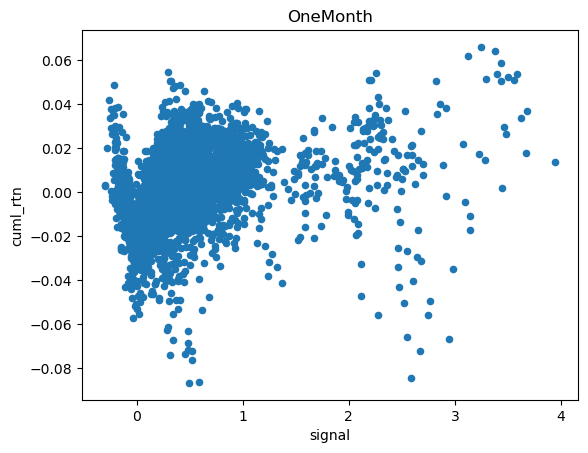

<Axes: title={'center': 'OneYear'}, xlabel='signal', ylabel='cuml_rtn'>

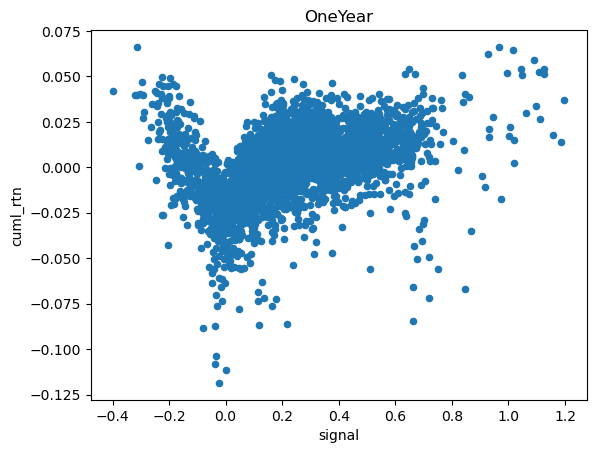

<Axes: title={'center': 'SixMonth'}, xlabel='signal', ylabel='cuml_rtn'>

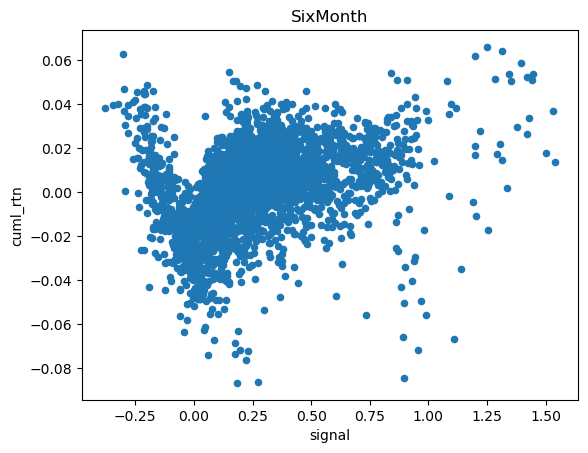

<Axes: title={'center': 'ThreeMonth'}, xlabel='signal', ylabel='cuml_rtn'>

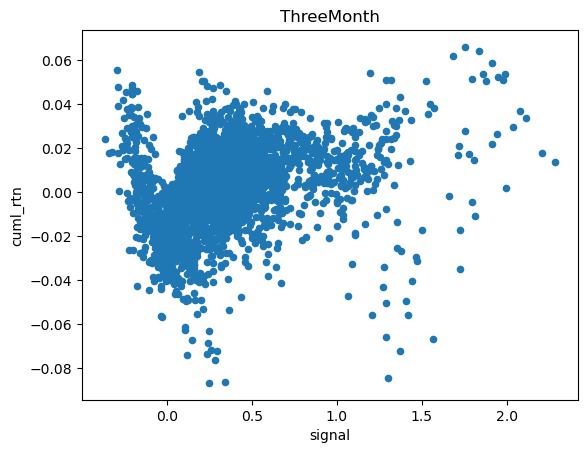

<Axes: title={'center': 'tmp'}, xlabel='signal', ylabel='cuml_rtn'>

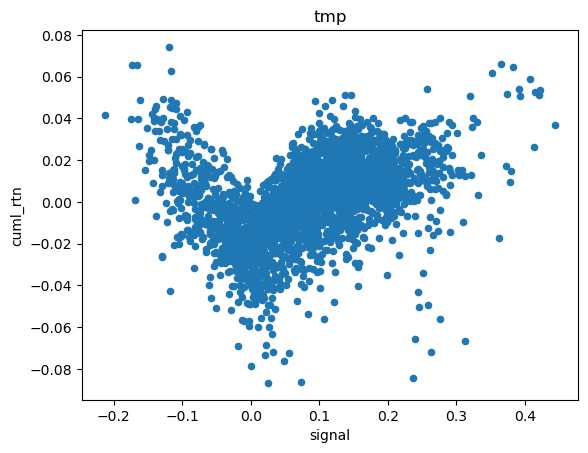

In [11]:
names = df_tmp.window.drop_duplicates().sort_values().to_list()
for name in names: 

    display(df_tmp
        .loc[lambda x: x.window == name]
        .assign(
            signal_rtn = lambda x: np.sign(x.signal) * x.px_rtn,
            vol_rtn    = lambda x: x.signal_rtn * (0.1 / (x.signal_rtn.ewm(span = 100, adjust = False).std() * np.sqrt(252))),
            cuml_rtn   = lambda x: x.vol_rtn.rolling(window = 10).sum(),
            year       = lambda x: pd.to_datetime(x.date).dt.year)
        .loc[lambda x: x.year != x.year.min()]
        .loc[lambda x: x.year != x.year.min()]
        .set_index("date")
        .plot(kind = "scatter", x = "signal", y = "cuml_rtn", title = name))
    plt.show()